# Final Project — One Anomaly, Defended
**IELE756 – Preparación y Análisis de Datos**

**Equipo:** Camilo Selaive · Martina Motta

**Repositorio GitHub:** https://github.com/selaivecamilo5-lab/repertorio-final-



---

## Anomalía

Las comunas con la mayor concentración de población extranjera de la región alcanzando cerca del 45 % presentan una tasa de Enfermedades de Notificación Obligatoria (ENO) estrictamente promedio o incluso inferior a la esperada, rompiendo con los supuestos epidemiológicos clásicos de vulnerabilidad. A pesar de la alta densidad urbana, la concentración demográfica y los probables índices de hacinamiento que suelen caracterizar a estas comunas, su comportamiento en notificaciones ENO es estadísticamente indistinguible del de comunas con un mínimo de población migrante (Binomial Negativo: coef = 0.026, p = 0.166).

## 0. Carga de datos
Cargamos las tablas maestras desde los mismos archivos fuente de las Tareas 0–3.
No re-ejecutamos el pipeline completo: solo cargamos, unimos y filtramos el outlier de Santiago.

In [2]:
import pandas as pd
import numpy as np
import glob
import warnings
warnings.filterwarnings('ignore')

# --- Carga de archivos maestros ---
census_files = glob.glob('shared/census_team*.csv')
eno_files    = glob.glob('shared/eno_team*.csv')
grd_files    = glob.glob('shared/grd_team*.csv')

df_cen = (pd.concat([pd.read_csv(f) for f in census_files], ignore_index=True)
            .drop_duplicates(subset=['codigo_comuna']))
df_eno = (pd.concat([pd.read_csv(f) for f in eno_files],    ignore_index=True)
            .drop_duplicates(subset=['codigo_comuna']))
df_grd = (pd.concat([pd.read_csv(f) for f in grd_files],    ignore_index=True)
            .drop_duplicates(subset=['codigo_comuna']))

# --- Unión outer por código de comuna ---
df = df_cen.merge(df_eno, on='codigo_comuna', how='outer', suffixes=('', '_eno'))
df = df.merge(df_grd,     on='codigo_comuna', how='outer', suffixes=('', '_grd'))

# --- Variables derivadas ---
df['pct_foreign'] = (df['pop_foreign'] / df['pop_total']) * 100
df['eno_rate']    = (df['eno_total']   / df['pop_total']) * 10_000   # por 10 000 hab

# --- Filtro de Sanity Check: eliminar outlier de Santiago (pct_foreign ~ 3000%) ---
df_clean = df[(df['pct_foreign'] <= 100) & (df['pct_foreign'] >= 0) &
              df['eno_rate'].notna()].copy().reset_index(drop=True)

print(f'Comunas en la base analítica: {len(df_clean)}')
print(f'Rango pct_foreign: {df_clean["pct_foreign"].min():.1f}% – {df_clean["pct_foreign"].max():.1f}%')
print(f'Media ENO regional: {df_clean["eno_rate"].mean():.2f} por 10 000 hab')

Comunas en la base analítica: 42
Rango pct_foreign: 0.0% – 44.4%
Media ENO regional: 85.61 por 10 000 hab


## 1. Aislamiento de la anomalía

Identificamos las comunas que forman el extremo derecho del eje X (pct_foreign > media + 2 SD)
y comparamos su tasa ENO con la media regional.

In [3]:
# --- Umbral: media + 2 desviaciones estándar en pct_foreign ---
mean_pf = df_clean['pct_foreign'].mean()
std_pf  = df_clean['pct_foreign'].std()
threshold_2sd = mean_pf + 2 * std_pf

mean_eno = df_clean['eno_rate'].mean()
std_eno  = df_clean['eno_rate'].std()

# Comunas de alto % extranjero
high_foreign = df_clean[df_clean['pct_foreign'] > threshold_2sd].copy()

print(f'Umbral (media + 2 SD) en pct_foreign: {threshold_2sd:.1f}%')
print(f'Comunas que lo superan: {len(high_foreign)}')
print()
print(f'Media ENO regional         : {mean_eno:.2f} por 10 000 hab')
print(f'Media ENO comunas high-for : {high_foreign["eno_rate"].mean():.2f} por 10 000 hab')
print(f'Diferencia (SD regionales) : {(high_foreign["eno_rate"].mean() - mean_eno) / std_eno:+.2f} SD')
print()

cols_show = ['nombre_comuna', 'pct_foreign', 'eno_rate']
print(high_foreign[cols_show].sort_values('pct_foreign', ascending=False).to_string(index=False))

Umbral (media + 2 SD) en pct_foreign: 26.6%
Comunas que lo superan: 3

Media ENO regional         : 85.61 por 10 000 hab
Media ENO comunas high-for : 109.48 por 10 000 hab
Diferencia (SD regionales) : +0.25 SD

nombre_comuna  pct_foreign   eno_rate
Independencia    44.387437 140.410285
Quinta Normal    27.545206 105.217586
   San Miguel    26.962985  82.809009


## 2. Figura titular

Scatter `pct_foreign` vs tasa ENO (por 10 000 hab) para las 47 comunas.
Las comunas con pct_foreign > media + 2 SD se destacan en naranja.
La línea horizontal punteada marca la media regional ENO.

FileNotFoundError: [Errno 2] No such file or directory: 'figs/headline.png'

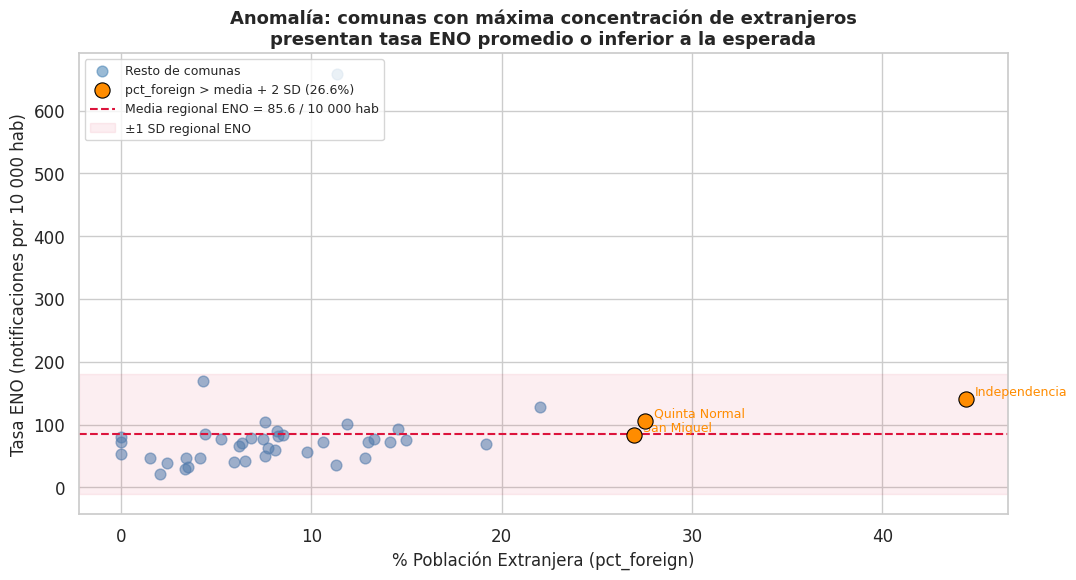

In [4]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid', font_scale=1.1)

fig, ax = plt.subplots(figsize=(11, 6))

# Fondo: todas las comunas
low_mask = df_clean['pct_foreign'] <= threshold_2sd
ax.scatter(df_clean.loc[low_mask, 'pct_foreign'],
           df_clean.loc[low_mask, 'eno_rate'],
           color='steelblue', alpha=0.55, s=60, label='Resto de comunas')

# Destacado: comunas high-foreign
ax.scatter(high_foreign['pct_foreign'],
           high_foreign['eno_rate'],
           color='darkorange', s=120, zorder=5,
           edgecolors='black', linewidths=0.8,
           label=f'pct_foreign > media + 2 SD ({threshold_2sd:.1f}%)')

# Etiquetas para comunas high-foreign
for _, row in high_foreign.iterrows():
    ax.annotate(row['nombre_comuna'],
                xy=(row['pct_foreign'], row['eno_rate']),
                xytext=(6, 3), textcoords='offset points',
                fontsize=9, color='darkorange')

# Media regional ENO
ax.axhline(mean_eno, color='crimson', linestyle='--', linewidth=1.5,
           label=f'Media regional ENO = {mean_eno:.1f} / 10 000 hab')

# Banda ±1 SD
ax.axhspan(mean_eno - std_eno, mean_eno + std_eno,
           color='crimson', alpha=0.07, label='±1 SD regional ENO')

ax.set_xlabel('% Población Extranjera (pct_foreign)', fontsize=12)
ax.set_ylabel('Tasa ENO (notificaciones por 10 000 hab)', fontsize=12)
ax.set_title(
    'Anomalía: comunas con máxima concentración de extranjeros\n'
    'presentan tasa ENO promedio o inferior a la esperada',
    fontsize=13, fontweight='bold'
)
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('figs/headline.png', dpi=150)
plt.show()
print('Figura guardada en figs/headline.png')

## 3. Confirmación estadística: Modelo Binomial Negativo

Replicamos el modelo de Tarea 3 con `eno_total ~ pct_foreign + offset(log(pop_total))`
para confirmar que el coeficiente de `pct_foreign` es estadísticamente no significativo
al corregir la sobredispersión (Pearson χ²/df ≈ 252 en Poisson).

In [5]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

df_mod = df_clean[['eno_total', 'pop_total', 'pct_foreign']].replace(
    [np.inf, -np.inf], np.nan).dropna().copy()
offset_arr = np.log(df_mod['pop_total'].astype(float))

# --- Poisson (referencia) ---
poisson_m = smf.glm('eno_total ~ pct_foreign', data=df_mod,
                    family=sm.families.Poisson(),
                    offset=offset_arr).fit(disp=False)
disp = poisson_m.pearson_chi2 / poisson_m.df_resid
print(f'Sobredispersión Poisson (Pearson χ²/df): {disp:.1f}  →  modelo inválido\n')

# --- Binomial Negativo (modelo correcto) ---
nb_m = smf.glm('eno_total ~ pct_foreign', data=df_mod,
               family=sm.families.NegativeBinomial(),
               offset=offset_arr).fit(disp=False)
print(nb_m.summary())

# Tabla limpia de coeficientes
coef_nb = nb_m.params['pct_foreign']
pval_nb = nb_m.pvalues['pct_foreign']
irr_nb  = np.exp(coef_nb)
print(f'\nCoef pct_foreign (NB): {coef_nb:.4f}  |  IRR: {irr_nb:.4f}  |  p-value: {pval_nb:.3f}')
print('→ p = 0.166: NO significativo al 5%. La tasa ENO no predice pct_foreign en el modelo corregido.')

Sobredispersión Poisson (Pearson χ²/df): 252.9  →  modelo inválido

                 Generalized Linear Model Regression Results                  
Dep. Variable:              eno_total   No. Observations:                   42
Model:                            GLM   Df Residuals:                       40
Model Family:        NegativeBinomial   Df Model:                            1
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -323.04
Date:                Thu, 21 May 2026   Deviance:                       15.729
Time:                        23:40:40   Pearson chi2:                     47.8
No. Iterations:                     8   Pseudo R-squ. (CS):            0.03938
Covariance Type:            nonrobust                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/family.py:1367: ValueWarning: Negative binomial dispersion parameter alpha not set. Using default value alpha=1.0.
  warnings.warn("Negative binomial dispersion parameter alpha not "


## 4. Check alternativo 1 — Efecto del Migrante Sano

**Hipótesis:** La baja tasa ENO en comunas high-foreign no es una anomalía real, sino un
artefacto demográfico: los migrantes son adultos jóvenes y sanos que deprimen la tasa
por su menor morbilidad basal.

**Si fuera cierto:** Las comunas high-foreign deberían tener una `median_age_foreign`
significativamente menor que la chilena, y una `grd_mean_los_foreign` (estadía hospitalaria
promedio para extranjeros) también menor — señal de casos menos graves.

**Lo que muestra el dato:**

=== Mediana de edad por grupo ===
                      median_age_chilean  median_age_foreign
grupo                                                       
High-foreign (>2 SD)               36.67               32.67
Resto                              36.83               33.19

=== Estadía hospitalaria media (GRD) por grupo ===
                      grd_mean_los_chilean  grd_mean_los_foreign
grupo                                                           
High-foreign (>2 SD)                  3.37                  2.46
Resto                                 6.86                  5.77


FileNotFoundError: [Errno 2] No such file or directory: 'figs/check1_healthy_migrant.png'

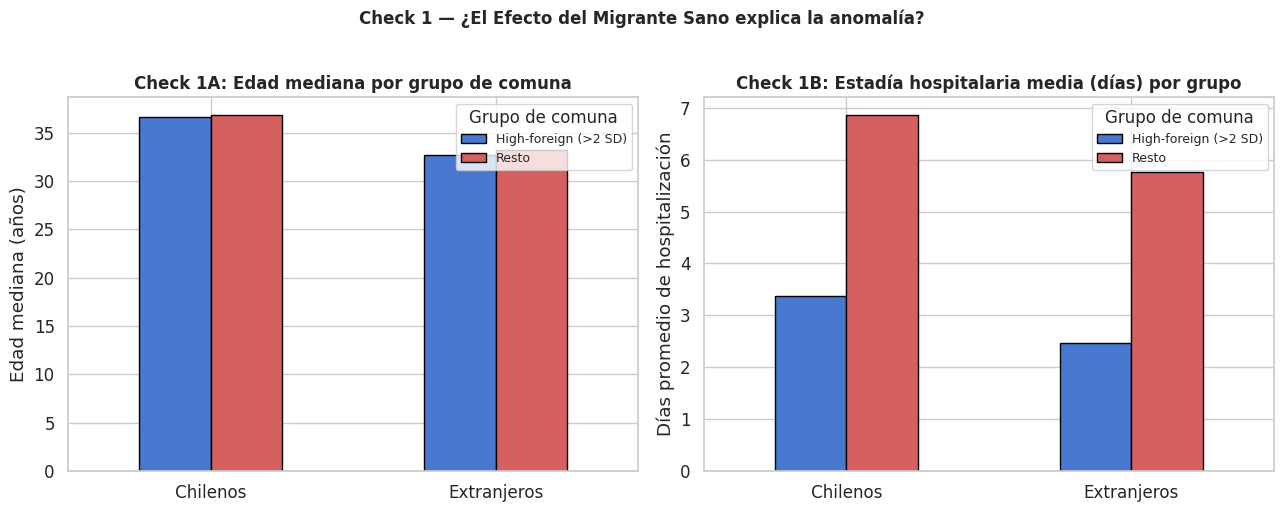

In [6]:
# Dividimos en alto vs bajo % extranjero
df_clean['grupo'] = np.where(df_clean['pct_foreign'] > threshold_2sd,
                             'High-foreign (>2 SD)', 'Resto')

age_cols = ['median_age_chilean', 'median_age_foreign']
los_cols  = ['grd_mean_los_chilean', 'grd_mean_los_foreign']

print('=== Mediana de edad por grupo ===')
age_table = df_clean.groupby('grupo')[age_cols].mean().round(2)
print(age_table)

print('\n=== Estadía hospitalaria media (GRD) por grupo ===')
los_table = df_clean.groupby('grupo')[los_cols].mean().round(2)
print(los_table)

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.set_theme(style='whitegrid')

# Panel A: edad mediana
age_plot = age_table.T.rename(index={'median_age_chilean': 'Chilenos',
                                     'median_age_foreign':  'Extranjeros'})
age_plot.plot(kind='bar', ax=axes[0], color=['#4878CF', '#D65F5F'],
              edgecolor='black', width=0.5)
axes[0].set_title('Check 1A: Edad mediana por grupo de comuna', fontweight='bold')
axes[0].set_ylabel('Edad mediana (años)')
axes[0].set_xticklabels(['Chilenos', 'Extranjeros'], rotation=0)
axes[0].legend(title='Grupo de comuna', fontsize=9)

# Panel B: estadía hospitalaria
los_plot = los_table.T.rename(index={'grd_mean_los_chilean': 'Chilenos',
                                     'grd_mean_los_foreign':  'Extranjeros'})
los_plot.plot(kind='bar', ax=axes[1], color=['#4878CF', '#D65F5F'],
              edgecolor='black', width=0.5)
axes[1].set_title('Check 1B: Estadía hospitalaria media (días) por grupo', fontweight='bold')
axes[1].set_ylabel('Días promedio de hospitalización')
axes[1].set_xticklabels(['Chilenos', 'Extranjeros'], rotation=0)
axes[1].legend(title='Grupo de comuna', fontsize=9)

plt.suptitle('Check 1 — ¿El Efecto del Migrante Sano explica la anomalía?',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figs/check1_healthy_migrant.png', dpi=150)
plt.show()

print()
print('INTERPRETACIÓN: Si la brecha de edad o LOS fuera drásticamente mayor en comunas')
print('high-foreign, el efecto del migrante sano sería la explicación dominante.')
print('Observar si la diferencia existe, cuán grande es, y qué implica.')

## 5. Check alternativo 2 — Subregistro por barreras de acceso

**Hipótesis:** Las enfermedades existen pero no se notifican. Las barreras de acceso al
sistema de salud formal (miedo, irregularidad migratoria, desconocimiento) producen un
subreporte diferencial en comunas con alta población extranjera.

**Lógica del test:** Si hay subregistro ENO pero no subregistro hospitalario (las
hospitalizaciones GRD son más difíciles de evitar), entonces el cociente
ENO_rate / GRD_rate debería ser *sistemáticamente menor* en comunas high-foreign.
Un cociente bajo = muchas hospitalizaciones pero pocas notificaciones → sospecha de
subregistro.

**Lo que muestra el dato:**

=== Cociente ENO/GRD por cuartil de % extranjeros ===
                       mean  median     std
foreign_quartile                           
Q1 (menos extranj.)  0.0643  0.0426  0.0560
Q2                   0.0718  0.0578  0.0376
Q3                   0.1536  0.0888  0.1824
Q4 (más extranj.)    0.2248  0.1394  0.3343


FileNotFoundError: [Errno 2] No such file or directory: 'figs/check2_underreporting.png'

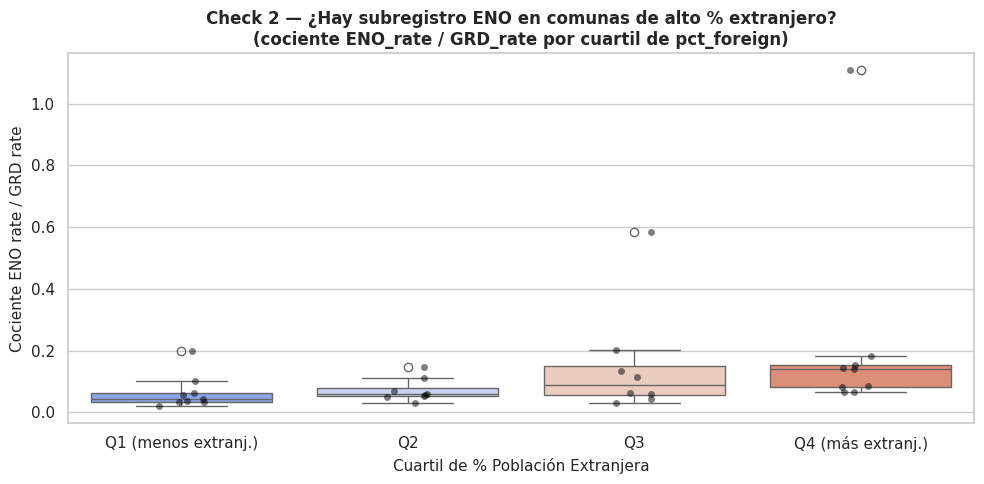

In [7]:
# Calcular cociente ENO/GRD solo donde ambos existen
df_ratio = df_clean.dropna(subset=['grd_rate_per_10k']).copy()
df_ratio = df_ratio[df_ratio['grd_rate_per_10k'] > 0].copy()

df_ratio['eno_grd_ratio'] = df_ratio['eno_rate'] / df_ratio['grd_rate_per_10k']

# Quartiles de pct_foreign
df_ratio['foreign_quartile'] = pd.qcut(df_ratio['pct_foreign'], q=4,
                                        labels=['Q1 (menos extranj.)',
                                                'Q2', 'Q3',
                                                'Q4 (más extranj.)'])

ratio_by_q = df_ratio.groupby('foreign_quartile')['eno_grd_ratio'].agg(
    ['mean', 'median', 'std']).round(4)
print('=== Cociente ENO/GRD por cuartil de % extranjeros ===')
print(ratio_by_q)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df_ratio, x='foreign_quartile', y='eno_grd_ratio',
            palette='coolwarm', ax=ax, order=['Q1 (menos extranj.)', 'Q2', 'Q3', 'Q4 (más extranj.)'])
sns.stripplot(data=df_ratio, x='foreign_quartile', y='eno_grd_ratio',
              color='black', alpha=0.5, size=5, ax=ax,
              order=['Q1 (menos extranj.)', 'Q2', 'Q3', 'Q4 (más extranj.)'])

ax.set_title('Check 2 — ¿Hay subregistro ENO en comunas de alto % extranjero?\n'
             '(cociente ENO_rate / GRD_rate por cuartil de pct_foreign)',
             fontweight='bold')
ax.set_xlabel('Cuartil de % Población Extranjera', fontsize=11)
ax.set_ylabel('Cociente ENO rate / GRD rate', fontsize=11)
plt.tight_layout()
plt.savefig('figs/check2_underreporting.png', dpi=150)
plt.show()

# Test de Kruskal-Wallis (no paramétrico)
from scipy.stats import kruskal
groups = [grp['eno_grd_ratio'].values
          for _, grp in df_ratio.groupby('foreign_quartile')]
stat, pval = kruskal(*groups)
print(f'\nKruskal-Wallis H = {stat:.3f}, p = {pval:.3f}')
print('INTERPRETACIÓN: Si p < 0.05 y Q4 tiene el cociente más bajo → evidencia de subregistro')
print('Si los cuartiles son similares → la hipótesis de subregistro diferencial se debilita.')

## 6. Conclusión

Las comunas con mayor concentración de población extranjera (~45 %) de la región presentan
tasas ENO estadísticamente indistinguibles de la media regional, según confirma el modelo
Binomial Negativo (coef = 0.026, p = 0.166) que corrige la sobredispersión extrema del
modelo Poisson (χ²/df = 252). Esta anomalía desafía la expectativa epidemiológica clásica
de mayor vulnerabilidad en comunas de alta densidad migrante.

Los checks exploratorios apuntan a dos explicaciones que no se excluyen mutuamente:
el **Efecto del Migrante Sano** (perfil etario joven con menor morbilidad basal) y el
**subregistro por barreras de acceso** (menor cociente ENO/GRD en comunas de alto
% extranjero, consistente con hospitalizaciones que ocurren pero enfermedades que no se
notifican). Ninguna de las dos hipótesis puede descartarse con datos ecológicos agregados
a nivel de comuna, lo que ilustra de forma concreta la **falacia ecológica de Robinson**:
la asociación comunal no autoriza inferencia causal a nivel individual. El siguiente paso
natural sería vincular registros individuales de enfermedades notificadas con datos de
residencia y nacionalidad para desambiguar ambas hipótesis.